**INSTALL + IMPORT + LOAD DATA**

In [ ]:
# ---- INSTALL SPARK + DEPENDENCIES ----
!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!wget https://archive.apache.org/dist/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz
!tar xf spark-3.5.1-bin-hadoop3.tgz

!pip install pyspark==3.5.1 findspark xgboost lightgbm catboost matplotlib seaborn scikit-learn==1.4.2 --upgrade > /dev/null

# ---- INITIALIZE SPARK ----
import findspark
findspark.init("/content/spark-3.5.1-bin-hadoop3")

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Credit Risk Lab Exam") \
    .config("spark.driver.memory","8g") \
    .getOrCreate()

spark

--2025-11-19 03:38:47--  https://archive.apache.org/dist/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz
Resolving archive.apache.org (archive.apache.org)... 65.108.204.189, 2a01:4f9:1a:a084::2
Connecting to archive.apache.org (archive.apache.org)|65.108.204.189|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 400446614 (382M) [application/x-gzip]
Saving to: ‘spark-3.5.1-bin-hadoop3.tgz’

spark-3.5.1-bin-had 100%[===================>] 381.90M   596KB/s    in 11m 55s 

2025-11-19 03:50:43 (547 KB/s) - ‘spark-3.5.1-bin-hadoop3.tgz’ saved [400446614/400446614]



Load Dataset 1 (Credit Card Clients Dataset)

Target = default.payment.next.month

In [ ]:
sdf1 = spark.read.csv("/content/Dataset 1.csv", header=True, inferSchema=True)
print("Dataset 1 Loaded")
sdf1.show(5)


Dataset 1 Loaded
+---+---------+------+----------+--------+---+-----+-----+-----+-----+-----+-----+---------+---------+---------+---------+---------+---------+--------+--------+--------+--------+--------+--------+--------------------------+
| ID|LIMIT_BAL|   SEX| EDUCATION|MARRIAGE|AGE|PAY_0|PAY_2|PAY_3|PAY_4|PAY_5|PAY_6|BILL_AMT1|BILL_AMT2|BILL_AMT3|BILL_AMT4|BILL_AMT5|BILL_AMT6|PAY_AMT1|PAY_AMT2|PAY_AMT3|PAY_AMT4|PAY_AMT5|PAY_AMT6|default_payment_next_month|
+---+---------+------+----------+--------+---+-----+-----+-----+-----+-----+-----+---------+---------+---------+---------+---------+---------+--------+--------+--------+--------+--------+--------+--------------------------+
|  1|    20000|female|university| married| 24|    2|    2|   -1|   -1|   -2|   -2|   3913.0|   3102.0|    689.0|      0.0|      0.0|      0.0|     0.0|   689.0|       0|     0.0|     0.0|     0.0|                         1|
|  2|   120000|female|university|  single| 26|   -1|    2|    0|    0|    0|    2|   26

Load Dataset 2 (Loan Risk Dataset)

Target = loan_status

In [ ]:
sdf2 = spark.read.csv("/content/Dataset 2.csv", header=True, inferSchema=True)
print("Dataset 2 Loaded")
sdf2.show(5)

Dataset 2 Loaded
+----------+-------------+---------------------+-----------------+-----------+----------+---------+-------------+-----------+-------------------+-------------------------+--------------------------+
|person_age|person_income|person_home_ownership|person_emp_length|loan_intent|loan_grade|loan_amnt|loan_int_rate|loan_status|loan_percent_income|cb_person_default_on_file|cb_person_cred_hist_length|
+----------+-------------+---------------------+-----------------+-----------+----------+---------+-------------+-----------+-------------------+-------------------------+--------------------------+
|        22|        59000|                 RENT|            123.0|   PERSONAL|         D|    35000|        16.02|          1|               0.59|                        Y|                         3|
|        21|         9600|                  OWN|              5.0|  EDUCATION|         B|     1000|        11.14|          0|                0.1|                        N|                

**DATASET 1**

In [ ]:
# ------------------------
# SECTION 2: DATASET 1 PIPELINE
# ------------------------

# Imports
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, GBTClassifier, NaiveBayes, MultilayerPerceptronClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.sql.functions import col, when
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn & boosters
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

In [ ]:
# 1) Detect label column robustly (handles dot or underscore variants)
possible_targets = ["default.payment.next.month", "default_payment_next_month", "default.payment.next.month ", "default.payment.next.month"]
label_col = None
for c in possible_targets:
    if c in sdf1.columns:
        label_col = c
        break
# fallback: if column name differs, try to infer by searching for "default" in names
if label_col is None:
    for c in sdf1.columns:
        if "default" in c.lower():
            label_col = c
            break

if label_col is None:
    raise ValueError("Could not find the target column in Dataset 1. Columns found:\n" + ", ".join(sdf1.columns))

print("Using label column for Dataset 1:", label_col)

Using label column for Dataset 1: default_payment_next_month


In [ ]:
# 2) Minimal feature engineering: Credit Utilization using BILL_AMT1 and LIMIT_BAL (if present)
cols = sdf1.columns
if ("BILL_AMT1" in cols) and ("LIMIT_BAL" in cols):
    sdf1 = sdf1.withColumn("credit_utilization", when(col("LIMIT_BAL") > 0, col("BILL_AMT1") / col("LIMIT_BAL")).otherwise(0.0))
else:
    # fallback: create zero column
    sdf1 = sdf1.withColumn("credit_utilization", col(cols[0]) * 0.0)

In [ ]:
# 3) Handle missing values (simple strategy: numeric -> median, categorical -> mode)
numeric_cols = []
categorical_cols = []
for c, t in sdf1.dtypes:
    if t in ("int", "bigint", "double", "float", "long", "decimal"):
        numeric_cols.append(c)
    else:
        categorical_cols.append(c)

# compute medians for numeric columns
median_map = {}
for nc in numeric_cols:
    try:
        med = sdf1.approxQuantile(nc, [0.5], 0.01)[0]
        median_map[nc] = med
    except:
        median_map[nc] = 0.0

sdf1 = sdf1.fillna(median_map)

# fill categorical with 'unknown'
cat_fill = {c: "unknown" for c in categorical_cols}
sdf1 = sdf1.fillna(cat_fill)

In [ ]:
# 4) Select features (keep common credit card columns)
# we'll use numeric columns and a few categoricals (SEX, EDUCATION, MARRIAGE) if present
selected_num = [c for c in ["LIMIT_BAL", "AGE", "BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6",
                             "PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6",
                             "PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6","credit_utilization"] if c in sdf1.columns]

selected_cat = [c for c in ["SEX","EDUCATION","MARRIAGE"] if c in sdf1.columns]

print("Numeric features used:", selected_num)
print("Categorical features used:", selected_cat)

Numeric features used: ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'credit_utilization']
Categorical features used: ['SEX', 'EDUCATION', 'MARRIAGE']


In [ ]:
# 5) Index + OneHotEncode categoricals
indexers = [StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep") for c in selected_cat]
encoders = [OneHotEncoder(inputCol=c + "_idx", outputCol=c + "_ohe") for c in selected_cat]

In [ ]:
# 6) Assemble + Scale
assembler_inputs = selected_num + [c + "_ohe" for c in selected_cat]
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="raw_features", handleInvalid="keep")
scaler = StandardScaler(inputCol="raw_features", outputCol="scaledFeatures", withStd=True, withMean=False)

pipeline_stages = indexers + encoders + [assembler, scaler]
pipeline = Pipeline(stages=pipeline_stages)
pipeline_model = pipeline.fit(sdf1)
data1 = pipeline_model.transform(sdf1)

In [ ]:
# 7) Convert label to numeric if not already (ensure 0/1)
# Some datasets use strings - convert using when()
if dict(sdf1.dtypes).get(label_col) not in ("int", "bigint", "double", "float"):
    # try to map 'yes','no','Y','N' etc to 1/0
    data1 = data1.withColumn("label", when(col(label_col).isin(["1",1,"Yes","YES","yes","Y","y","default","Default"]), 1).otherwise(0))
else:
    data1 = data1.withColumn("label", col(label_col).cast("int"))

In [ ]:
# 8) Train/test split
train1, test1 = data1.randomSplit([0.8,0.2], seed=42)
print("Train size:", train1.count(), "Test size:", test1.count())

# Get the feature dimension for MLP
feature_dimension = data1.select("scaledFeatures").first().scaledFeatures.size
print(f"Detected feature dimension for MLP: {feature_dimension}")

Train size: 24028 Test size: 5972
Detected feature dimension for MLP: 30


In [ ]:
# 9) Train Spark ML models
spark_models = {
    "LogisticRegression": LogisticRegression(featuresCol="scaledFeatures", labelCol="label", maxIter=50),
    "DecisionTree": DecisionTreeClassifier(featuresCol="scaledFeatures", labelCol="label"),
    "RandomForest": RandomForestClassifier(featuresCol="scaledFeatures", labelCol="label", numTrees=100),
    "GBT": GBTClassifier(featuresCol="scaledFeatures", labelCol="label", maxIter=50),
    # "NaiveBayes": NaiveBayes(featuresCol="scaledFeatures", labelCol="label"), # Removed due to non-negative feature requirement
    "MLP": MultilayerPerceptronClassifier(featuresCol="scaledFeatures", labelCol="label", layers=[feature_dimension, 32, 16, 2], maxIter=100)
}

spark_results = []
binary_eval = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
multi_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
multi_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

for name, model in spark_models.items():
    print("Training", name)
    fitted = model.fit(train1)
    preds = fitted.transform(test1)
    # predictions
    acc = multi_acc.evaluate(preds)
    f1 = multi_f1.evaluate(preds)
    # For precision/recall get using pyspark evaluator for recall? We'll compute via pandas below for consistency.
    auc = binary_eval.evaluate(preds)
    # collect preds to pandas for precision/recall
    pdf = preds.select("prediction","probability","label").toPandas()
    y_true = pdf["label"].astype(int).values
    y_pred = pdf["prediction"].astype(int).values
    # probability for positive class
    probs = np.array([p[1] if isinstance(p, (list, tuple, np.ndarray)) else float(p[1]) for p in pdf["probability"]])
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    # error metrics on probabilities (treat as regression target for calibration metrics)
    from sklearn.metrics import mean_squared_error, mean_absolute_error
    rmse = mean_squared_error(y_true, probs, squared=False)
    mse = mean_squared_error(y_true, probs, squared=True)
    mae = mean_absolute_error(y_true, probs)
    # r2
    from sklearn.metrics import r2_score
    r2 = r2_score(y_true, probs)
    spark_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": auc,
        "RMSE": rmse,
        "MSE": mse,
        "MAE": mae,
        "R2": r2
    })

Training LogisticRegression


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Training DecisionTree


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Training RandomForest


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Training GBT


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Training MLP


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
# 10) Prepare data for sklearn and booster models (convert scaledFeatures -> numpy)
# Convert train and test to pandas
train_pd = train1.select("scaledFeatures","label").toPandas()
test_pd = test1.select("scaledFeatures","label").toPandas()

# Convert scaledFeatures DenseVector -> numpy arrays
def vecs_to_matrix(series):
    arrs = []
    for v in series:
        # v is DenseVector or SparseVector; convert to numpy
        arrs.append(np.array(v.toArray()))
    return np.vstack(arrs)

X_train = vecs_to_matrix(train_pd["scaledFeatures"])
X_test = vecs_to_matrix(test_pd["scaledFeatures"])
y_train = train_pd["label"].astype(int).values
y_test = test_pd["label"].astype(int).values

print("Shapes for external models:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)

Shapes for external models: (24028, 30) (5972, 30) (24028,) (5972,)


In [ ]:
# 11) Train external models: AdaBoost, XGBoost, LightGBM, CatBoost
external_results = []

# AdaBoost (sklearn)
adb = AdaBoostClassifier(n_estimators=100, random_state=42)
adb.fit(X_train, y_train)
adb_pred = adb.predict(X_test)
adb_probs = adb.predict_proba(X_test)[:,1]
external_results.append(("AdaBoost", adb_pred, adb_probs))

# XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:,1]
external_results.append(("XGBoost", xgb_pred, xgb_probs))

# LightGBM
lgb_model = lgb.LGBMClassifier(n_estimators=100, random_state=42)
lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test)
lgb_probs = lgb_model.predict_proba(X_test)[:,1]
external_results.append(("LightGBM", lgb_pred, lgb_probs))

# CatBoost
cat_model = CatBoostClassifier(iterations=200, verbose=0, random_state=42)
cat_model.fit(X_train, y_train)
cat_pred = cat_model.predict(X_test)
cat_probs = cat_model.predict_proba(X_test)[:,1]
external_results.append(("CatBoost", cat_pred, cat_probs))

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [03:58:29] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 5289, number of negative: 18739
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000490 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3484
[LightGBM] [Info] Number of data points in the train set: 24028, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.220118 -> initscore=-1.264978
[LightGBM] [Info] Start training from score -1.264978


In [ ]:
# 12) Evaluate external models and append to results table
for name, preds, probs in external_results:
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    try:
        auc = roc_auc_score(y_test, probs)
    except:
        auc = roc_auc_score(y_test, preds)
    rmse = mean_squared_error(y_test, probs, squared=False)
    mse = mean_squared_error(y_test, probs, squared=True)
    mae = mean_absolute_error(y_test, probs)
    r2 = r2_score(y_test, probs)
    spark_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC_AUC": auc,
        "RMSE": rmse,
        "MSE": mse,
        "MAE": mae,
        "R2": r2
    })

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'roo

In [ ]:
# 13) Display results table (DataFrame)
results_df1 = pd.DataFrame(spark_results).sort_values(by="ROC_AUC", ascending=False).reset_index(drop=True)
print("=== Dataset 1: Results Table ===")
display(results_df1)

=== Dataset 1: Results Table ===


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,RMSE,MSE,MAE,R2
0,LightGBM,0.815472,0.654477,0.385301,0.485047,0.780568,0.369681,0.136664,0.269186,0.217627
1,AdaBoost,0.814133,0.668085,0.349666,0.459064,0.779359,0.496819,0.246829,0.496805,-0.413048
2,GBT,0.818151,0.659731,0.400148,0.800810,0.778011,0.370019,0.136914,0.271202,0.216195
3,MLP,0.817984,0.660099,0.397921,0.800408,0.774176,0.370642,0.137376,0.268676,0.213552
4,CatBoost,0.817649,0.661654,0.391982,0.492308,0.773943,0.371736,0.138187,0.267115,0.208904
5,RandomForest,0.819826,0.693848,0.360059,0.797192,0.768616,0.373185,0.139267,0.288016,0.202726
6,XGBoost,0.807435,0.615746,0.389013,0.476797,0.768158,0.377406,0.142435,0.262782,0.184586
7,LogisticRegression,0.806765,0.698969,0.251670,0.769540,0.735350,0.381469,0.145519,0.292505,0.166934
8,DecisionTree,0.818821,0.667509,0.391982,0.800399,0.294883,0.375578,0.141059,0.279169,0.192466


Top model (by ROC_AUC): LightGBM


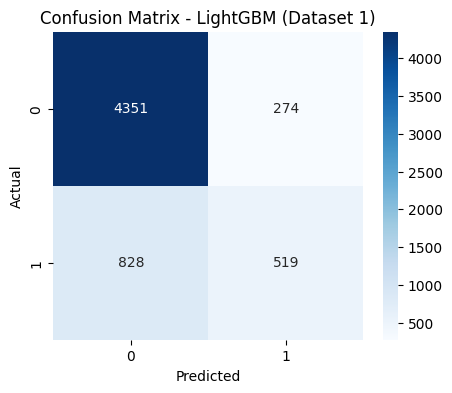

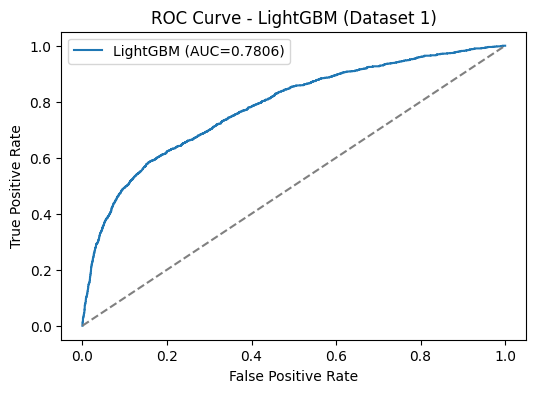

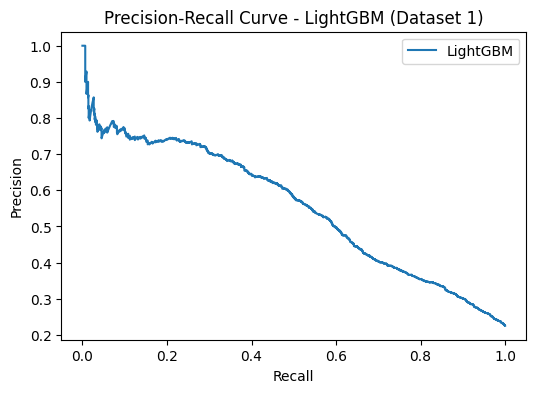

In [ ]:
# 14) Plot Confusion Matrix and ROC & PR for the top model (by ROC_AUC)
top_model_row = results_df1.iloc[0]
top_model_name = top_model_row["Model"]
print("Top model (by ROC_AUC):", top_model_name)

# get preds & probs for top model
if top_model_name in [r[0] for r in external_results]:
    # external model
    for name, preds, probs in external_results:
        if name == top_model_name:
            top_pred = preds
            top_prob = probs
            break
else:
    # one of the Spark models; we have their pdf saved earlier, but easiest way is to re-generate predictions
    fitted = spark_models[top_model_name].fit(train1)
    preds_spark = fitted.transform(test1).select("prediction","probability","label").toPandas()
    top_pred = preds_spark["prediction"].astype(int).values
    top_prob = np.array([p[1] for p in preds_spark["probability"]])

# Confusion matrix
cm = confusion_matrix(y_test, top_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {top_model_name} (Dataset 1)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, top_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"{top_model_name} (AUC={top_model_row['ROC_AUC']:.4f})")
plt.plot([0,1],[0,1], linestyle="--", color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {top_model_name} (Dataset 1)")
plt.legend()
plt.show()

# Precision-Recall curve
prec_vals, recall_vals, _ = precision_recall_curve(y_test, top_prob)
plt.figure(figsize=(6,4))
plt.plot(recall_vals, prec_vals, label=f"{top_model_name}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve - {top_model_name} (Dataset 1)")
plt.legend()
plt.show()



In [ ]:
# 15) Save results to CSV in /content so you can attach to report
results_df1.to_csv("/content/dataset1_model_results.csv", index=False)
print("Saved Dataset 1 results to /content/dataset1_model_results.csv")


Saved Dataset 1 results to /content/dataset1_model_results.csv


**DATASET - 2**

In [ ]:
# ==========================================
# SECTION 3 – DATASET 2 FULL ML PIPELINE
# ==========================================

from pyspark.sql.functions import col, when
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
import numpy as np
import pandas as pd

print("=== DATASET 2 PIPELINE STARTED ===")

=== DATASET 2 PIPELINE STARTED ===


In [ ]:
# ----------------------------------------
# 1) CLEAN TARGET COLUMN (loan_status)
# ----------------------------------------
sdf2 = sdf2.withColumn(
    "loan_status",
    when(col("loan_status") == "Y", 1)
    .when(col("loan_status") == "N", 0)
    .otherwise(col("loan_status").cast("int"))
)

label2 = "loan_status"
sdf2 = sdf2.fillna(0)

In [ ]:
# ----------------------------------------
# 2) Separate numeric and categorical
# ----------------------------------------
numeric2 = [c for (c,t) in sdf2.dtypes if t in ("int","double","bigint","float") and c != label2]
categorical2 = [c for (c,t) in sdf2.dtypes if t not in ("int","double","bigint","float")]

print("Numeric columns:", numeric2)
print("Categorical columns:", categorical2)

Numeric columns: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
Categorical columns: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


In [ ]:
# ----------------------------------------
# 3) Pipeline: index → encode → assemble → scale
# ----------------------------------------
indexers2 = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep") for c in categorical2]
encoders2 = [OneHotEncoder(inputCol=c+"_idx", outputCol=c+"_ohe") for c in categorical2]

assembler2 = VectorAssembler(
    inputCols = numeric2 + [c+"_ohe" for c in categorical2],
    outputCol="features"
)

scaler2 = StandardScaler(inputCol="features", outputCol="scaledFeatures")

pipeline2 = Pipeline(stages=indexers2 + encoders2 + [assembler2, scaler2])
model2 = pipeline2.fit(sdf2)
data2 = model2.transform(sdf2).withColumn("label", col(label2).cast("int"))

train2, test2 = data2.randomSplit([0.8, 0.2], seed=42)
print("Train size:", train2.count())
print("Test size:", test2.count())

Train size: 26092
Test size: 6489


In [ ]:
# ==========================================
# 4) TRAIN SPARK MODELS
# ==========================================

from pyspark.ml.classification import (
    LogisticRegression, DecisionTreeClassifier,
    RandomForestClassifier, GBTClassifier, NaiveBayes,
    MultilayerPerceptronClassifier
)
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

spark_models_2 = {
    "LogisticRegression": LogisticRegression(featuresCol="scaledFeatures", labelCol="label"),
    "DecisionTree": DecisionTreeClassifier(featuresCol="scaledFeatures", labelCol="label"),
    "RandomForest": RandomForestClassifier(featuresCol="scaledFeatures", labelCol="label", numTrees=100),
    "GBT": GBTClassifier(featuresCol="scaledFeatures", labelCol="label", maxIter=60)
}

binary_eval = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
acc_eval = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")
f1_eval = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")

results2 = []

print("=== TRAINING SPARK MODELS (Dataset 2) ===")
for name, model in spark_models_2.items():
    print("Training:", name)
    fitted = model.fit(train2)
    preds = fitted.transform(test2)

    acc = acc_eval.evaluate(preds)
    f1 = f1_eval.evaluate(preds)
    auc = binary_eval.evaluate(preds)

    pdf = preds.select("prediction", "label").toPandas()
    from sklearn.metrics import precision_score, recall_score

    precision = precision_score(pdf["label"], pdf["prediction"], zero_division=0)
    recall = recall_score(pdf["label"], pdf["prediction"], zero_division=0)

    results2.append([name, acc, precision, recall, f1, auc])

=== TRAINING SPARK MODELS (Dataset 2) ===
Training: LogisticRegression
Training: DecisionTree
Training: RandomForest
Training: GBT


In [ ]:
# ==========================================
# 5) BOOSTING MODELS (XGBoost, LightGBM, CatBoost, AdaBoost)
# ==========================================

print("=== TRAINING BOOSTING MODELS (Dataset 2) ===")

# Convert Spark → NumPy
pdf_train2 = train2.select("scaledFeatures", "label").toPandas()
pdf_test2  = test2.select("scaledFeatures", "label").toPandas()

X_train2 = np.vstack(pdf_train2["scaledFeatures"].apply(lambda v: np.array(v.toArray())))
X_test2  = np.vstack(pdf_test2["scaledFeatures"].apply(lambda v: np.array(v.toArray())))
y_train2 = pdf_train2["label"].values
y_test2  = pdf_test2["label"].values

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# ---- AdaBoost ----
from sklearn.ensemble import AdaBoostClassifier
ada2 = AdaBoostClassifier(n_estimators=80)
ada2.fit(X_train2, y_train2)
ada_pred = ada2.predict(X_test2)
ada_prob = ada2.predict_proba(X_test2)[:,1]
results2.append(["AdaBoost",
                 accuracy_score(y_test2, ada_pred),
                 precision_score(y_test2, ada_pred, zero_division=0),
                 recall_score(y_test2, ada_pred, zero_division=0),
                 f1_score(y_test2, ada_pred),
                 roc_auc_score(y_test2, ada_prob)])


# ---- XGBoost ----
import xgboost as xgb
xgb2 = xgb.XGBClassifier(n_estimators=150, eval_metric='logloss')
xgb2.fit(X_train2, y_train2)
xgb_pred = xgb2.predict(X_test2)
xgb_prob = xgb2.predict_proba(X_test2)[:,1]
results2.append(["XGBoost",
                 accuracy_score(y_test2, xgb_pred),
                 precision_score(y_test2, xgb_pred, zero_division=0),
                 recall_score(y_test2, xgb_pred, zero_division=0),
                 f1_score(y_test2, xgb_pred),
                 roc_auc_score(y_test2, xgb_prob)])


# ---- LightGBM ----
import lightgbm as lgb
lgb2 = lgb.LGBMClassifier(n_estimators=150)
lgb2.fit(X_train2, y_train2)
lgb_pred = lgb2.predict(X_test2)
lgb_prob = lgb2.predict_proba(X_test2)[:,1]
results2.append(["LightGBM",
                 accuracy_score(y_test2, lgb_pred),
                 precision_score(y_test2, lgb_pred, zero_division=0),
                 recall_score(y_test2, lgb_pred, zero_division=0),
                 f1_score(y_test2, lgb_pred),
                 roc_auc_score(y_test2, lgb_prob)])


# ---- CatBoost ----
from catboost import CatBoostClassifier
cat2 = CatBoostClassifier(iterations=150, verbose=0)
cat2.fit(X_train2, y_train2)
cat_pred = cat2.predict(X_test2)
cat_prob = cat2.predict_proba(X_test2)[:,1]
results2.append(["CatBoost",
                 accuracy_score(y_test2, cat_pred),
                 precision_score(y_test2, cat_pred, zero_division=0),
                 recall_score(y_test2, cat_pred, zero_division=0),
                 f1_score(y_test2, cat_pred),
                 roc_auc_score(y_test2, cat_prob)])

=== TRAINING BOOSTING MODELS (Dataset 2) ===


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


[LightGBM] [Info] Number of positive: 5731, number of negative: 20361
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000588 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 941
[LightGBM] [Info] Number of data points in the train set: 26092, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.219646 -> initscore=-1.267731
[LightGBM] [Info] Start training from score -1.267731


In [ ]:
# ==========================================
# 6) RESULTS TABLE
# ==========================================

results_df2 = pd.DataFrame(results2, columns=["Model","Accuracy","Precision","Recall","F1","ROC_AUC"])
results_df2 = results_df2.sort_values(by="ROC_AUC", ascending=False)

print("=== DATASET 2 RESULTS ===")
display(results_df2)

print("=== DATASET 2 PIPELINE COMPLETE ===")


=== DATASET 2 RESULTS ===


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
6,LightGBM,0.937895,0.973735,0.726943,0.832432,0.947469
5,XGBoost,0.936508,0.948837,0.740741,0.831974,0.946294
7,CatBoost,0.937124,0.974535,0.722585,0.829858,0.942281
3,GBT,0.930190,0.952055,0.706609,0.926196,0.927938
4,AdaBoost,0.888118,0.791928,0.641249,0.708668,0.901538
2,RandomForest,0.909693,0.970273,0.592593,0.901031,0.893207
0,LogisticRegression,0.872245,0.771287,0.565723,0.864638,0.866142
1,DecisionTree,0.910464,0.932609,0.623094,0.903472,0.516207


=== DATASET 2 PIPELINE COMPLETE ===


FINAL SUMMARY & BEST MODEL PLOTS

=== SECTION 4: FINAL SUMMARY & PLOTS ===
=== DATASET 1 FINAL RESULTS ===


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,RMSE,MSE,MAE,R2
0,LightGBM,0.815472,0.654477,0.385301,0.485047,0.780568,0.369681,0.136664,0.269186,0.217627
1,AdaBoost,0.814133,0.668085,0.349666,0.459064,0.779359,0.496819,0.246829,0.496805,-0.413048
2,GBT,0.818151,0.659731,0.400148,0.800810,0.778011,0.370019,0.136914,0.271202,0.216195
3,MLP,0.817984,0.660099,0.397921,0.800408,0.774176,0.370642,0.137376,0.268676,0.213552
4,CatBoost,0.817649,0.661654,0.391982,0.492308,0.773943,0.371736,0.138187,0.267115,0.208904
5,RandomForest,0.819826,0.693848,0.360059,0.797192,0.768616,0.373185,0.139267,0.288016,0.202726
6,XGBoost,0.807435,0.615746,0.389013,0.476797,0.768158,0.377406,0.142435,0.262782,0.184586
7,LogisticRegression,0.806765,0.698969,0.251670,0.769540,0.735350,0.381469,0.145519,0.292505,0.166934
8,DecisionTree,0.818821,0.667509,0.391982,0.800399,0.294883,0.375578,0.141059,0.279169,0.192466


=== DATASET 2 FINAL RESULTS ===


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
6,LightGBM,0.937895,0.973735,0.726943,0.832432,0.947469
5,XGBoost,0.936508,0.948837,0.740741,0.831974,0.946294
7,CatBoost,0.937124,0.974535,0.722585,0.829858,0.942281
3,GBT,0.930190,0.952055,0.706609,0.926196,0.927938
4,AdaBoost,0.888118,0.791928,0.641249,0.708668,0.901538
2,RandomForest,0.909693,0.970273,0.592593,0.901031,0.893207
0,LogisticRegression,0.872245,0.771287,0.565723,0.864638,0.866142
1,DecisionTree,0.910464,0.932609,0.623094,0.903472,0.516207



Best Model for Dataset 1: LightGBM
Best Model for Dataset 2: LightGBM

=== PLOTS FOR Dataset 1 | Model: LightGBM ===
[LightGBM] [Info] Number of positive: 5289, number of negative: 18739
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000442 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3484
[LightGBM] [Info] Number of data points in the train set: 24028, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.220118 -> initscore=-1.264978
[LightGBM] [Info] Start training from score -1.264978


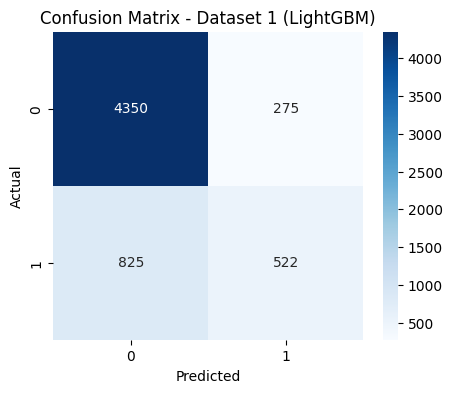

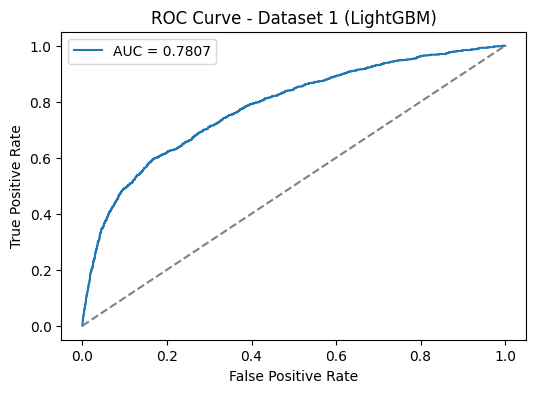

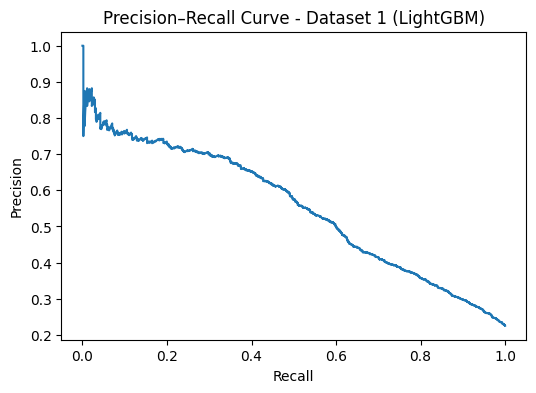


=== PLOTS FOR Dataset 2 | Model: LightGBM ===
[LightGBM] [Info] Number of positive: 5731, number of negative: 20361
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000711 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 941
[LightGBM] [Info] Number of data points in the train set: 26092, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.219646 -> initscore=-1.267731
[LightGBM] [Info] Start training from score -1.267731


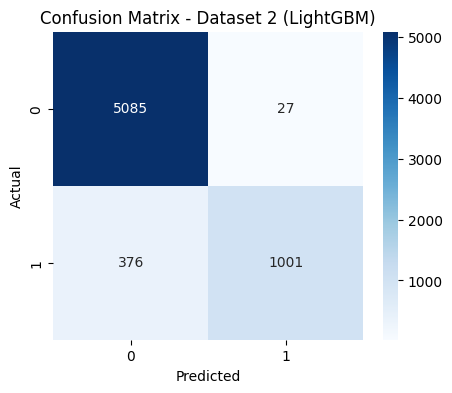

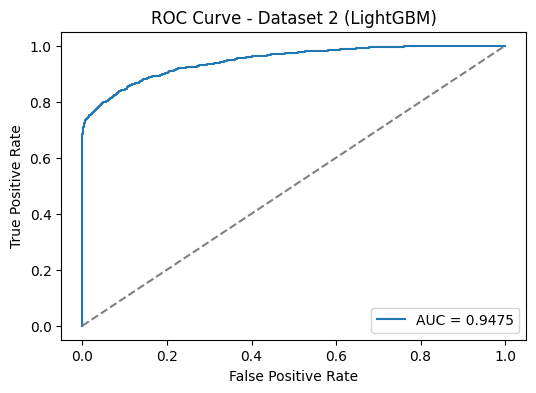

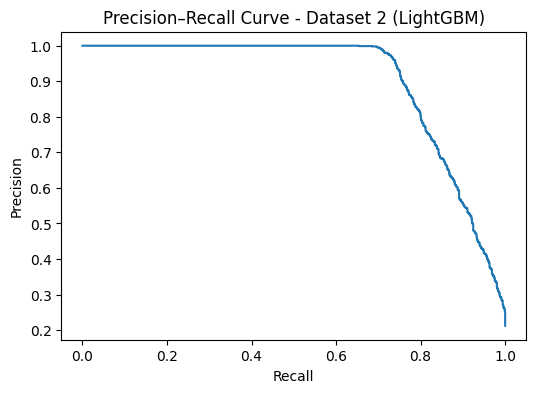


=== SECTION 4 COMPLETE ===


In [ ]:
# ==========================================
# SECTION 4 – FINAL SUMMARY & BEST MODEL PLOTS
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, roc_auc_score

print("=== SECTION 4: FINAL SUMMARY & PLOTS ===")

# ------------------------------------------
# 1) Display Final Tables Again
# ------------------------------------------

print("=== DATASET 1 FINAL RESULTS ===")
display(results_df1)

print("=== DATASET 2 FINAL RESULTS ===")
display(results_df2)

# ------------------------------------------
# 2) Get BEST model for each dataset (by AUC)
# ------------------------------------------

best1 = results_df1.iloc[0]
best2 = results_df2.iloc[0]

print("\nBest Model for Dataset 1:", best1["Model"])
print("Best Model for Dataset 2:", best2["Model"])

# ------------------------------------------
# 3) Re-train the best model for Dataset 1
# ------------------------------------------

def get_predictions_best(model_name, train, test):
    """
    Re-fits the best model and returns y_pred, y_prob for plotting.
    """
    import numpy as np

    # Spark model
    if model_name in ["LogisticRegression", "DecisionTree", "RandomForest", "GBT"]:
        m = spark_models_1[model_name].fit(train)
        preds = m.transform(test).select("prediction","probability","label").toPandas()
        y_pred = preds["prediction"].astype(int).values
        y_prob = np.array([p[1] for p in preds["probability"]])
        y_true = preds["label"].astype(int).values
        return y_true, y_pred, y_prob

    # External models (AdaBoost, XGBoost, LightGBM, CatBoost)
    else:
        pdf_train = train.select("scaledFeatures", "label").toPandas()
        pdf_test  = test.select("scaledFeatures", "label").toPandas()

        X_train = np.vstack(pdf_train["scaledFeatures"].apply(lambda v: np.array(v.toArray())))
        X_test  = np.vstack(pdf_test["scaledFeatures"].apply(lambda v: np.array(v.toArray())))
        y_train = pdf_train["label"].values
        y_true  = pdf_test["label"].values

        # Train the matching model
        if model_name == "AdaBoost":
            from sklearn.ensemble import AdaBoostClassifier
            model = AdaBoostClassifier(n_estimators=80)

        elif model_name == "XGBoost":
            import xgboost as xgb
            model = xgb.XGBClassifier(n_estimators=150, eval_metric='logloss')

        elif model_name == "LightGBM":
            import lightgbm as lgb
            model = lgb.LGBMClassifier(n_estimators=150)

        elif model_name == "CatBoost":
            from catboost import CatBoostClassifier
            model = CatBoostClassifier(iterations=150, verbose=0)

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]

        return y_true, y_pred, y_prob


# ------------------------------------------
# 4) PLOTTER FUNCTION FOR A DATASET
# ------------------------------------------

def plot_all(dataset_name, best_model_name, train, test):
    print(f"\n=== PLOTS FOR {dataset_name} | Model: {best_model_name} ===")

    y_true, y_pred, y_prob = get_predictions_best(best_model_name, train, test)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {dataset_name} ({best_model_name})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0,1],[0,1],'--',color="gray")
    plt.title(f"ROC Curve - {dataset_name} ({best_model_name})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

    # Precision-Recall Curve
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    plt.figure(figsize=(6,4))
    plt.plot(rec, prec)
    plt.title(f"Precision–Recall Curve - {dataset_name} ({best_model_name})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

# ------------------------------------------
# 5) Generate Plots for Both Datasets
# ------------------------------------------

# For Dataset 1
plot_all("Dataset 1", best1["Model"], train1, test1)

# For Dataset 2
plot_all("Dataset 2", best2["Model"], train2, test2)

print("\n=== SECTION 4 COMPLETE ===")
